# 02 — Baseline Accessibility Model

Population → road network → nearest facility travel time, computed via a single multi-source Dijkstra run from all facility-snapped graph nodes. Methodology detail in `../docs/manuscript.md` §3.3.

In [1]:
import pickle
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROC = Path('../data/processed')

with open(DATA_PROC / 'baseline_travel_time.pickle', 'rb') as f:
    travel_time = pickle.load(f)

nodes = np.array(list(travel_time.keys()))
times = np.array(list(travel_time.values()))
print(f'{len(times):,} reachable nodes')
print(f'median {np.median(times):.1f} min, p90 {np.percentile(times, 90):.1f} min, max {times.max():.1f} min')

541,290 reachable nodes
median 13.7 min, p90 54.4 min, max 179.3 min


## Travel-time map

Every reachable road-network node, colored by minutes to the nearest facility.

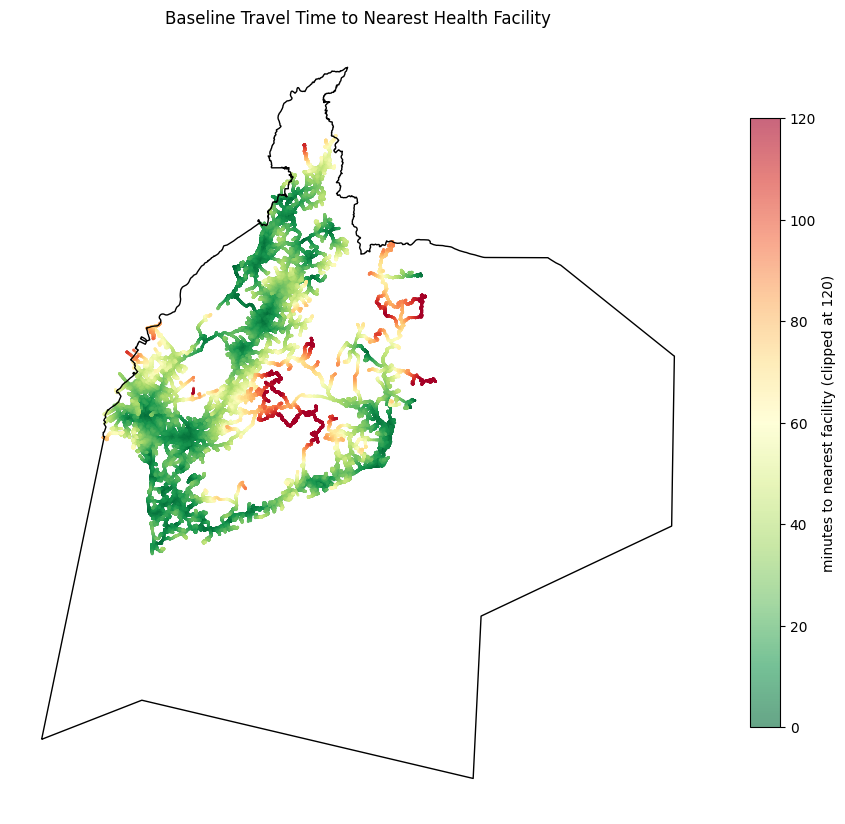

In [2]:
province = gpd.read_file(Path('../data/raw/kalsel_boundary.geojson'))

fig, ax = plt.subplots(figsize=(9, 9))
sc = ax.scatter(nodes[:, 0], nodes[:, 1], c=np.clip(times, 0, 120), cmap='RdYlGn_r', s=1, alpha=0.6)
province.boundary.plot(ax=ax, color='black', linewidth=1)
plt.colorbar(sc, ax=ax, label='minutes to nearest facility (clipped at 120)', shrink=0.7)
ax.set_title('Baseline Travel Time to Nearest Health Facility')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Distribution

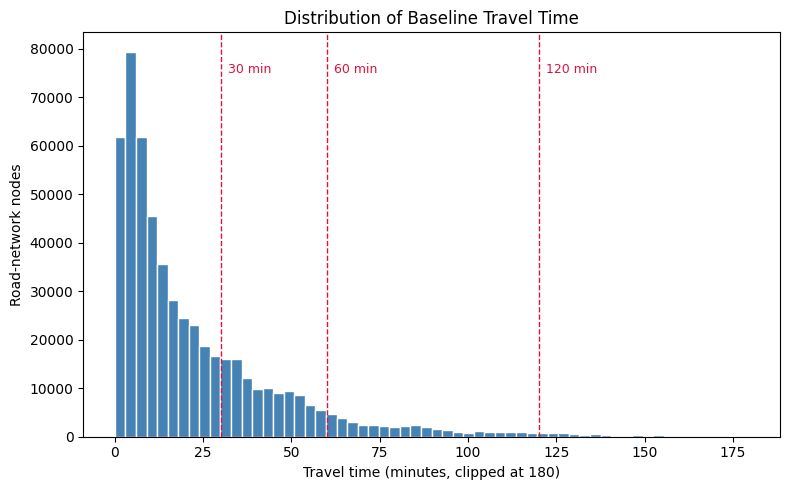

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.clip(times, 0, 180), bins=60, color='steelblue', edgecolor='white')
for t, label in [(30, '30 min'), (60, '60 min'), (120, '120 min')]:
    ax.axvline(t, color='crimson', linestyle='--', linewidth=1)
    ax.text(t + 2, ax.get_ylim()[1]*0.9, label, color='crimson', fontsize=9)
ax.set_xlabel('Travel time (minutes, clipped at 180)')
ax.set_ylabel('Road-network nodes')
ax.set_title('Distribution of Baseline Travel Time')
plt.tight_layout()
plt.show()

## Population-weighted summary

The headline numbers from `../docs/phase1_summary.md`, reproduced here directly from the pickled results.

In [4]:
with open(DATA_PROC / 'population_weighted_results.pickle', 'rb') as f:
    results = pickle.load(f)

for label, (pops, scenario_times) in results.items():
    valid = ~np.isnan(scenario_times)
    total = pops.sum()
    print(f'\n{label}')
    for t in [30, 60, 120]:
        within = pops[valid][scenario_times[valid] <= t].sum()
        print(f'  within {t} min: {100*within/total:.1f}%')


BASELINE (normal conditions)
  within 30 min: 64.8%
  within 60 min: 78.4%
  within 120 min: 83.0%

FLOOD-DISRUPTED — severe (all medium+high hazard edges removed)
  within 30 min: 14.8%
  within 60 min: 21.6%
  within 120 min: 25.1%

FLOOD-DISRUPTED — moderate (high removed, medium penalized 2.5x)
  within 30 min: 31.0%
  within 60 min: 39.5%
  within 120 min: 43.6%
